# Módulo 3 - Desafio 3
## Preparación de datos y gráficos

En este documento realizaremos una serie de pasos para poner en práctica los conocimientos adquiridos sobre preparación de datos y gráficos.

In [19]:
# Cargamos los datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_worlddata = pd.read_csv('world-data-2023.csv')
df_worlddata.head()

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.10%,"652,230","323,000",32.49,93.0,Kabul,"8,672",...,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273",33.939110,67.709953
1,Albania,105,AL,43.10%,"28,748","9,000",11.78,355.0,Tirana,"4,536",...,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593",41.153332,20.168331
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",...,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100",28.033886,1.659626
3,Andorra,164,AD,40.00%,468,NaN,7.20,376.0,Andorra la Vella,469,...,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873",42.506285,1.521801
4,Angola,26,AO,47.50%,"1,246,700","117,000",40.73,244.0,Luanda,"34,693",...,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025",-11.202692,17.873887


In [20]:
display(df_worlddata.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    195 non-null    object 
 1   Density
(P/Km2)                            195 non-null    object 
 2   Abbreviation                               188 non-null    object 
 3   Agricultural Land( %)                      188 non-null    object 
 4   Land Area(Km2)                             194 non-null    object 
 5   Armed Forces size                          171 non-null    object 
 6   Birth Rate                                 189 non-null    float64
 7   Calling Code                               194 non-null    float64
 8   Capital/Major City                         192 non-null    object 
 9   Co2-Emissions                              188 non-null    object 
 10  CPI                       

None

### Paso 1
Carga los datos y genera un dataFrame que excluya las columnas correspondientes
a la abreviatura del país, código de llamada, capital, código de moneda, ciudad más
grande, lenguaje oficial, latitud y longitud. Considerando estos datos, realiza una
inspección inicial sobre ellos, considerando gráficos. Concluye.

In [21]:
# Filtramos las columnas no deseadas
columns_to_exclude = ['Abbreviation', 'Calling Code', 'Capital/Major City', 'Currency-Code', 'Largest city', 'Official language', 'Latitude', 'Longitude']
df_worlddata.drop(columns=columns_to_exclude, inplace=True)

In [22]:
# Revisamos los valores nulos de cada columna
df_worlddata.isna().sum().sort_values(ascending=False)

Minimum wage                                 45
Tax revenue (%)                              26
Armed Forces size                            24
Gasoline Price                               20
Population: Labor force participation (%)    19
Unemployment rate                            19
CPI                                          17
CPI Change (%)                               16
Maternal mortality ratio                     14
Gross tertiary education enrollment (%)      12
Total tax rate                               12
Life expectancy                               8
Out of pocket health expenditure              7
Gross primary education enrollment (%)        7
Physicians per thousand                       7
Co2-Emissions                                 7
Agricultural Land( %)                         7
Forested Area (%)                             7
Fertility Rate                                7
Infant mortality                              6
Birth Rate                              

Podemos observar que hay varias columnas con valores nulos, por lo que si queremos trabajar con estos datos tendremos que considerar limpiar los nulos. Vemos también que hay un salto de línea dentro del nombre de la columna densidad; lo corregiremos, y revisaremos el dataset usando describe.

In [23]:
# Corregimos un typo de la columna 'Density\n(P/Km2)'
df_worlddata.rename(columns={'Density\n(P/Km2)': 'Density (P/Km2)'}, inplace=True)

# Revisamos las estadísticas descriptivas
display(df_worlddata.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,195,195,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Density (P/Km2),195,137,25,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Agricultural Land( %),188,168,17.40%,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Land Area(Km2),194,194,"652,230",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Armed Forces size,171,105,"2,000",7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Birth Rate,189.0,NaN,NaN,NaN,20.214974,9.945774,5.9,11.3,17.95,28.75,46.08
Co2-Emissions,188,184,"28,284",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CPI,178,175,106.58,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CPI Change (%),179,86,1.80%,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fertility Rate,188.0,NaN,NaN,NaN,2.698138,1.282267,0.98,1.705,2.245,3.5975,6.91


Vemos que existen varios columnas que deben ser preparadas para poder realizar un análisis exhaustivo del dataset. Por ejemplo, columnas que consideran un valor numerico pero que se encuentran almacenados como string u objeto; valores expresados con porcentaje, números expresados con '$,$', o que contiene el signo '$'. En el mismo sentido, podemos observar que no tenemos variables categóricas en el dataset, solo valores númericos que estan expresados como dinero, porcentaje, o usando comas como separador de miles.

In [24]:
# Revisamos columnas numéricas para análisis gráfico
num_cols = df_worlddata.select_dtypes(include=['number']).columns.tolist()
print("Columnas numéricas detectadas:", num_cols)

Columnas numéricas detectadas: ['Birth Rate', 'Fertility Rate', 'Infant mortality', 'Life expectancy', 'Maternal mortality ratio', 'Physicians per thousand']


In [25]:
# Corregimos el dato de GDP para poder revisarlo gráficamente
df_worlddata['GDP'] = df_worlddata['GDP']\
                        .str.replace('$', '')\
                        .str.replace(',', '')\
                        .astype(float)
display(df_worlddata['GDP'].describe())


count    1.930000e+02
mean     4.772959e+11
std      2.172173e+12
min      4.727146e+07
25%      8.454620e+09
50%      3.438723e+10
75%      2.340940e+11
max      2.142770e+13
Name: GDP, dtype: float64

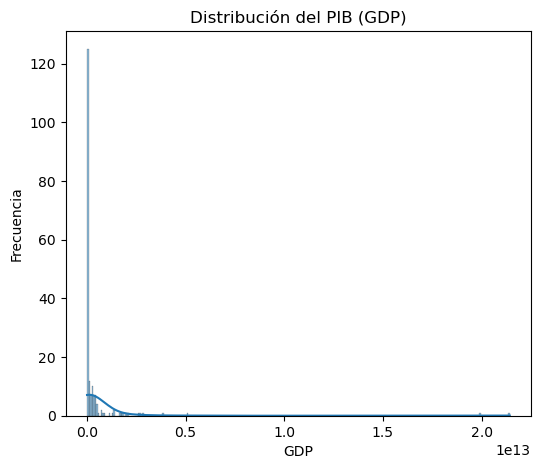

In [26]:
# Creamos un grafico de distribucion para la columna GDP
plt.figure(figsize=(6, 5))
sns.histplot(df_worlddata['GDP'].dropna(), kde=True)
plt.title('Distribución del PIB (GDP)')
plt.xlabel('GDP')
plt.ylabel('Frecuencia')
plt.show()

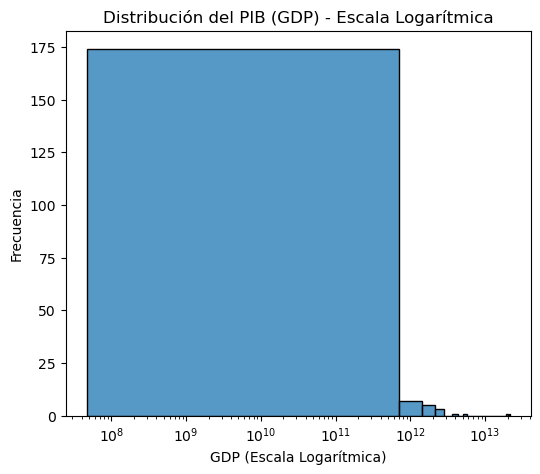

In [27]:
# Histograma de la columna 'GDP' pero expresado con escala logarítmica
plt.figure(figsize=(6, 5))
sns.histplot(df_worlddata['GDP'].dropna(), bins=30)
plt.xscale('log')
plt.title('Distribución del PIB (GDP) - Escala Logarítmica')
plt.xlabel('GDP (Escala Logarítmica)')
plt.ylabel('Frecuencia')
plt.show()

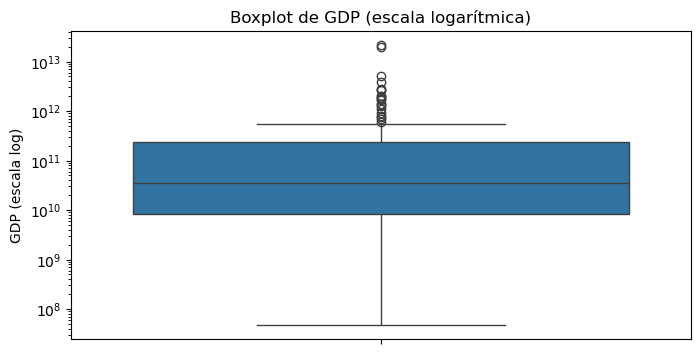

In [28]:
# Por último, un boxplot de la columna 'GDP' con escala logarítmica
plt.figure(figsize=(8,4))
sns.boxplot(y=df_worlddata['GDP'].dropna())
plt.yscale('log')
plt.ylabel('GDP (escala log)')
plt.title('Boxplot de GDP (escala logarítmica)')
plt.show()

Podemos observar que la mayor parte de los datos de GDP se concentran cerca del orden de $10^10$ y $10^11$, y que hay algunos outliers que se escapan dos o tres ordenes de magnitud sobre la media. Además, necesitaremos transformar este dato si queremos usarlo para buscar correlaciones con otras variables.

### Paso 2

De las variables codificadas numéricamente, ¿hay pares de ellas en la que parezca
haber correlación? ¿Para cuál(es) de ellas se observa más claramente?

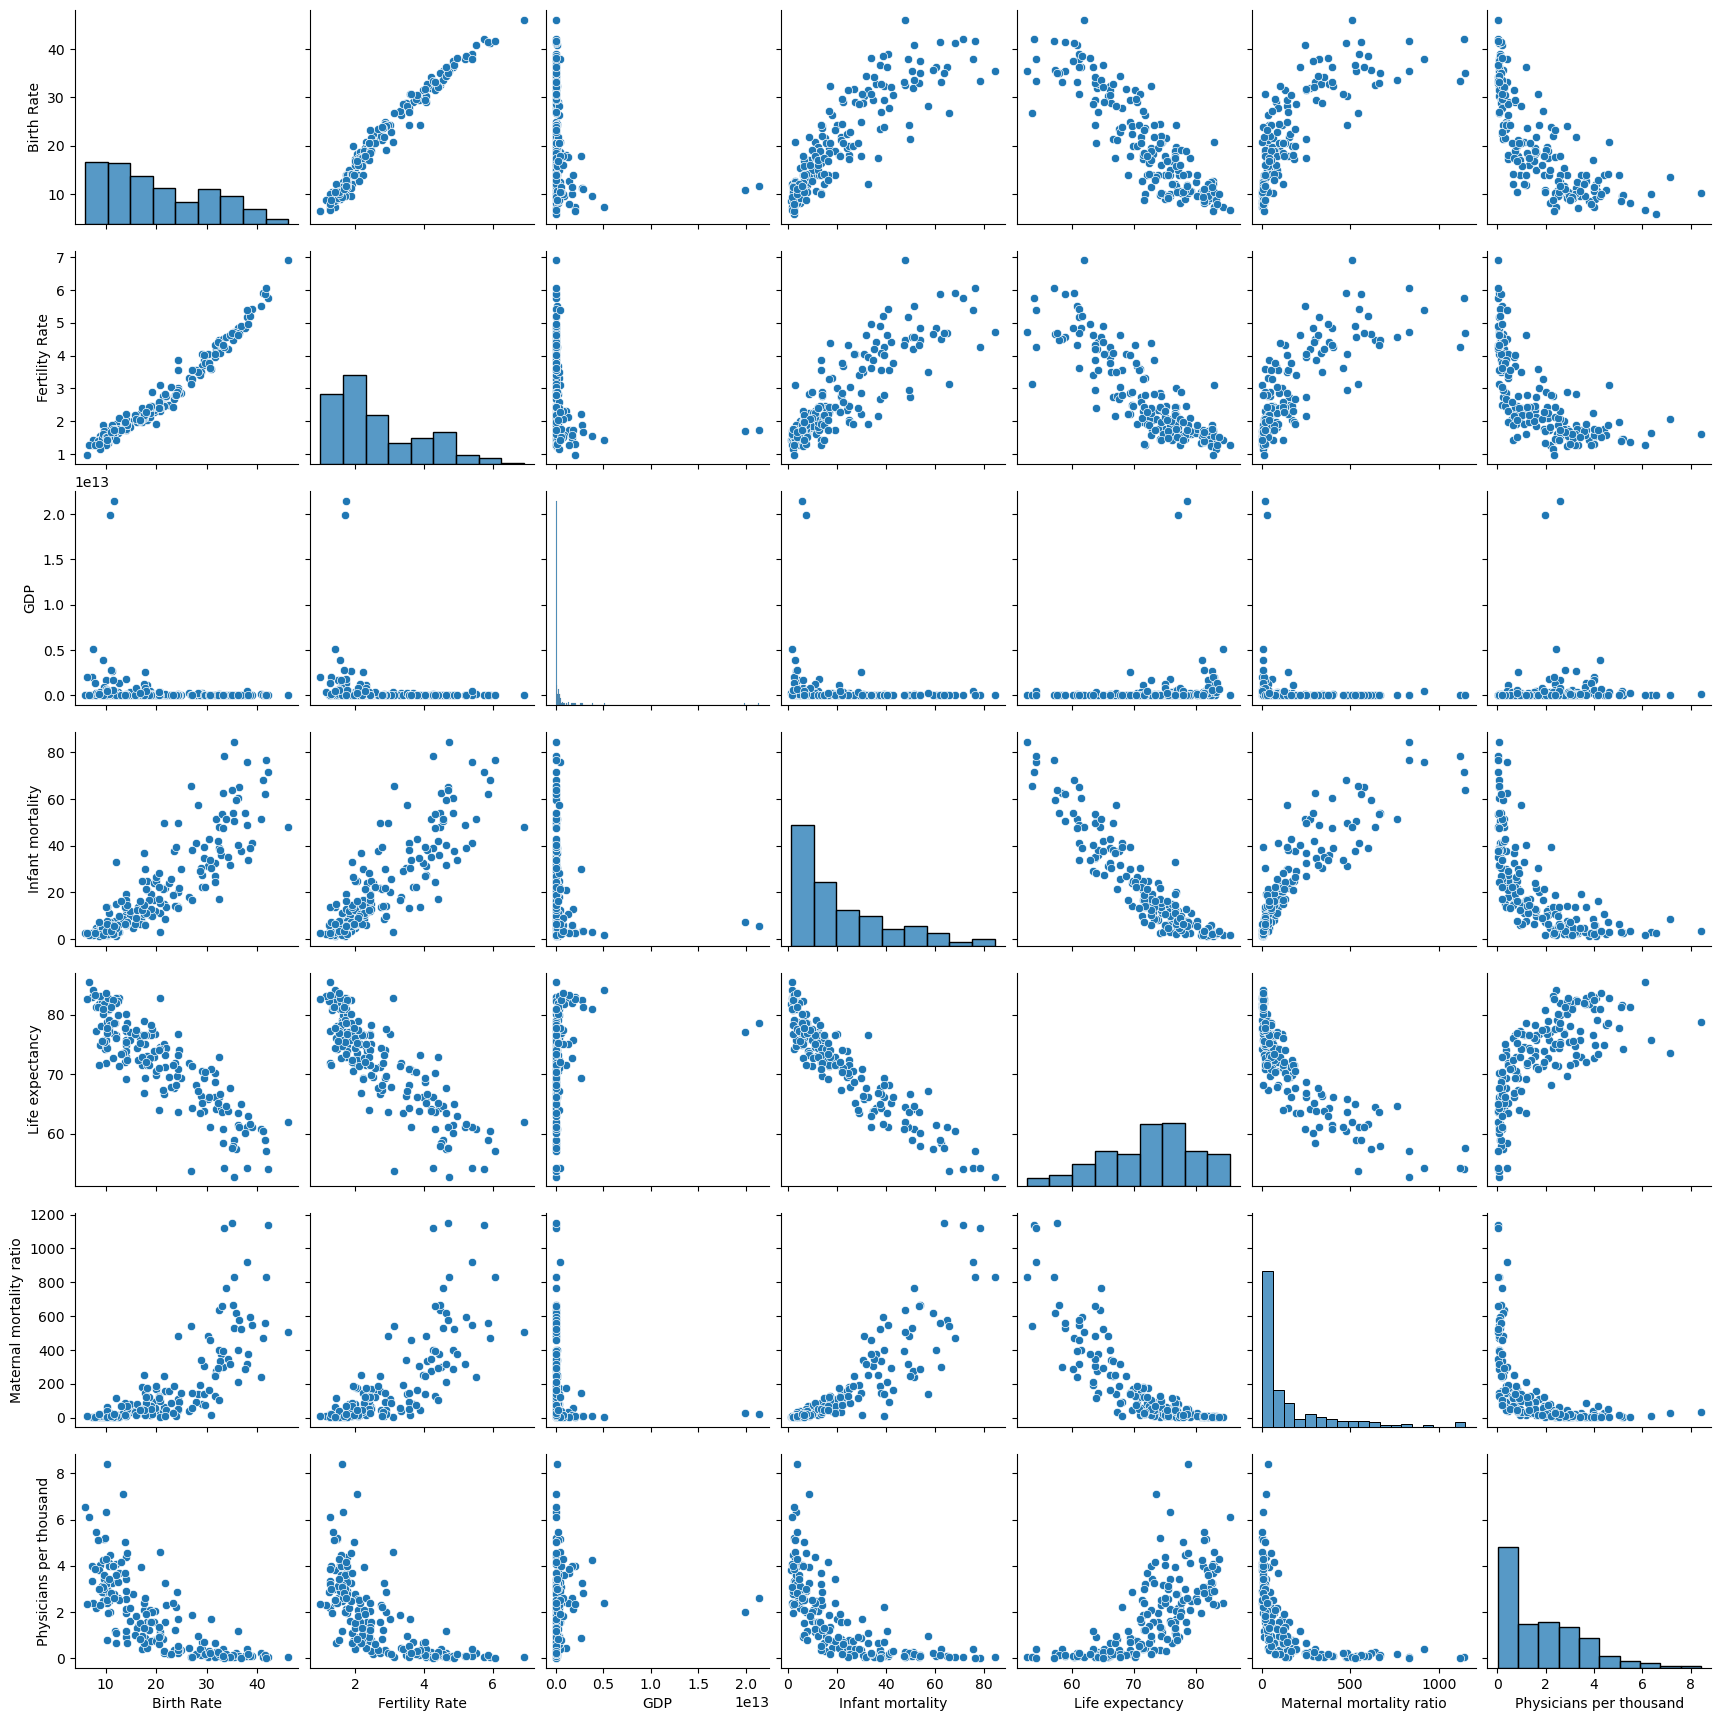

In [29]:
# Visualizamos las relaciones entre estas variables numéricas
sns.pairplot(df_worlddata)

Se puede observar los siguiente:
- La tasa de natalidad y de fertilidad estan directamente relacionadas.
- Hay una relación inversa entre la esperanza de vida y la tasa de natalidad, de fertilidad y de mortalidad infantil. Es decir, en países con mayor esperanza de vida nacen y mueren menos infantes.
- La cantidad de médicos cada 1000 habitantes esta correlacionada inversamente con la mortalidad infantil, y directamente con la esperanza de vida. Más médicos, menos muertes de infantes y mayor esperanza de vida.
- La tasa mortalidad materna tiene la mayor parte de sus datos concentrados cerca del 0, y el resto se encuentran dispersados. En general, mueren pocas madres.
- El GDP tiene la mayor parte de su data concentrada, lo que se refleja en las lineas rectas que muestran sus graficos. No se aprecian una relación directa con el resto de variables.
- Casi todas las columnas tienen datos fuera de la distribución, o que se alejan mucho del promedio.


La correlación más evidente corresponde a la primera mencionada; la tasa de natalidad y de fertilidad están fuertemente relacionadas.

### Paso 3
Considera los dos pares de variables anteriores y elimina en cada caso los faltantes y atípicos. Justifica en cada caso tu procedimiento.

___

Consideraremos el par de variables con mayor correlación (tasa de natalidad y fertilidad), y la expectativa de vida con la tasa de mortalidad infantil. Eliminaremos los valores nulos por comodidad al momento de aplicar funciones sobre los datos.

Veamos la relación de estos datos:

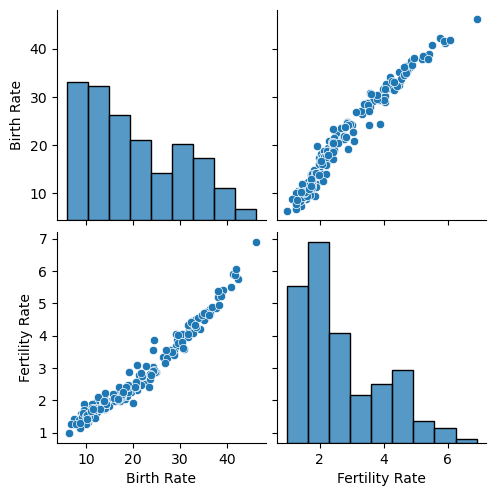

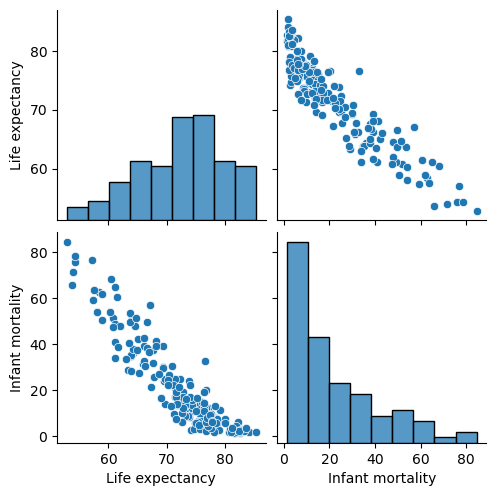

In [30]:
# Definimos los pares de variables a analizar
pair_1 = ['Birth Rate', 'Fertility Rate']
pair_2 = ['Life expectancy', 'Infant mortality']

sns.pairplot(df_worlddata, vars=pair_1)
sns.pairplot(df_worlddata, vars=pair_2)

Nuevamente podemos ver que la tasa de fertilidad y natalidad se encuentran fuertemente relacionadas, mientras que la esperanza de vida esta inversamente relacionada con la tasa de mortalidad infantil.

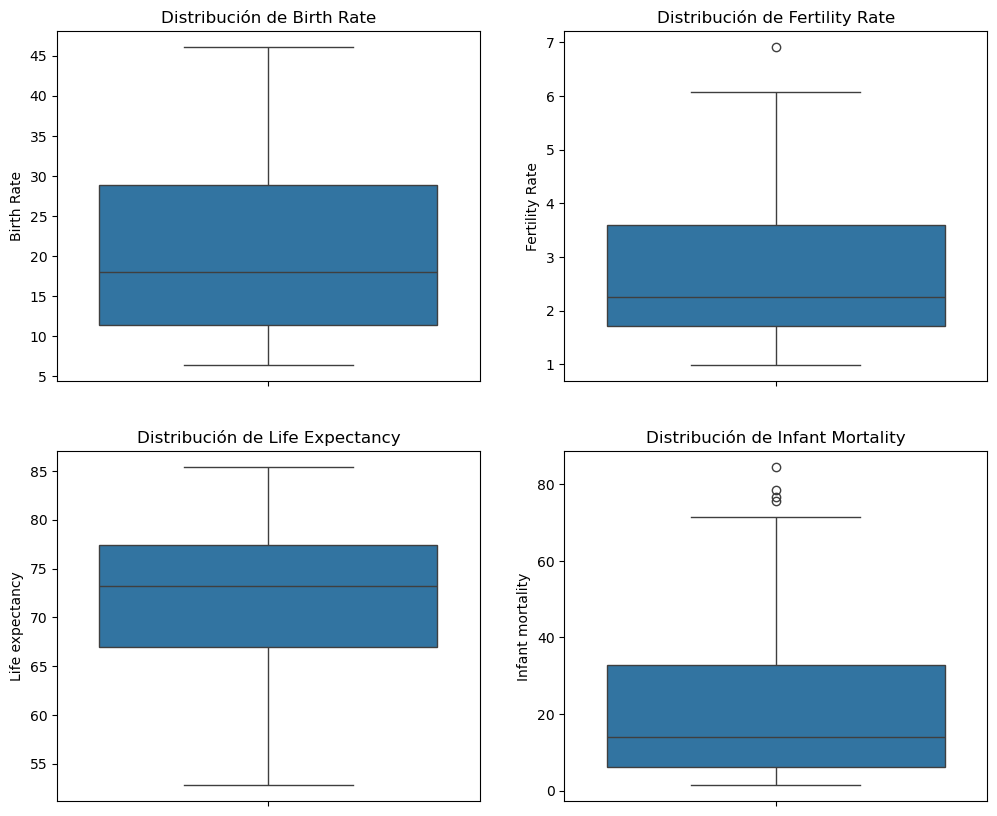

In [31]:
# Filtramos los datos para eliminar nulos en los pares seleccionados
df_pair1 = df_worlddata[pair_1].dropna().copy()
df_pair2 = df_worlddata[pair_2].dropna().copy()

# Revisemos la distribución de cada variable
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.boxplot(data=df_pair1['Birth Rate'], ax=axes[0, 0])
axes[0, 0].set_title('Distribución de Birth Rate')
sns.boxplot(data=df_pair1['Fertility Rate'], ax=axes[0, 1])
axes[0, 1].set_title('Distribución de Fertility Rate')
sns.boxplot(data=df_pair2['Life expectancy'], ax=axes[1, 0])
axes[1, 0].set_title('Distribución de Life Expectancy')
sns.boxplot(data=df_pair2['Infant mortality'], ax=axes[1, 1])
axes[1, 1].set_title('Distribución de Infant Mortality')
plt.show()

Podemos observar que tanto la tasa de natalidad como la tasa de mortalidad infantil presentan outliers o valores atípicos.Limpiaremos estas columnas utilizando la medida IQR

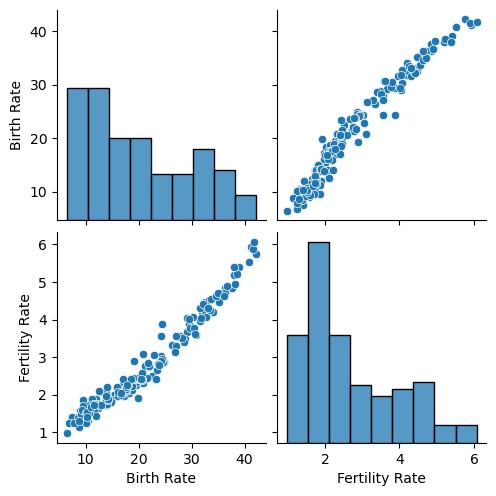

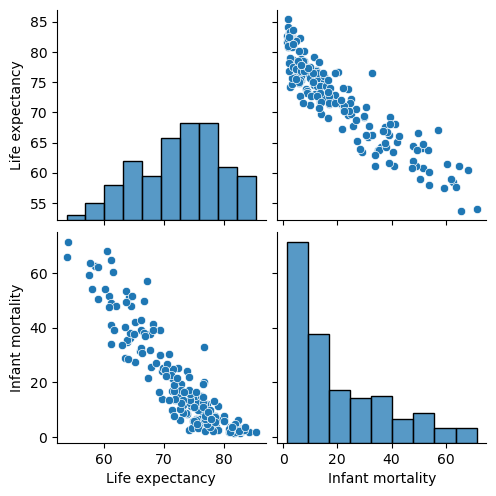

In [32]:
# Definimos una funcion para eliminar outliers usando el método del rango intercuartílico (IQR)
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Limpiamos los outliers en ambos pares de variables
df_pair1_clean = remove_outliers_iqr(df_pair1, 'Fertility Rate')
df_pair2_clean = remove_outliers_iqr(df_pair2, 'Infant mortality')

# y visualizamos las relaciones limpias
sns.pairplot(df_pair1_clean, vars=pair_1)
sns.pairplot(df_pair2_clean, vars=pair_2)

### Paso 4
Construye un gráfico para verificar la correlación entre estas variables, ahora con los datos preparados. Compara con lo obtenido anteriormente.
___
Se observa levemente una distribución más homogénea de los datos, puesto que estos datos ya se apreciaban antes de la limpieza que estaba correlacionados. Ahora calcularemos la correlación de estas variables.

In [33]:
df_pair1.loc[:, pair_1].corr()

,Birth Rate,Fertility Rate
Birth Rate,1.000000,0.981069
Fertility Rate,0.981069,1.000000


In [34]:
df_pair1_clean.loc[:, pair_1].corr()

,Birth Rate,Fertility Rate
Birth Rate,1.000000,0.981516
Fertility Rate,0.981516,1.000000


<Axes: >

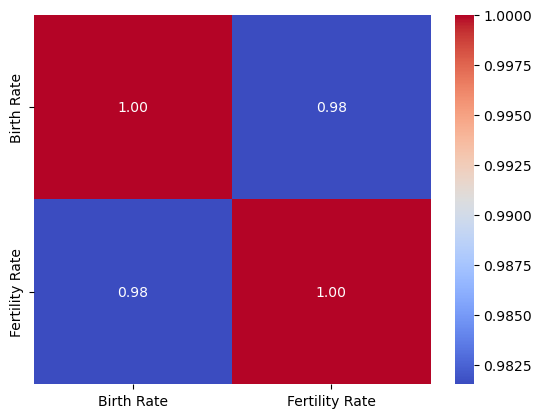

In [35]:
sns.heatmap(df_pair1_clean.loc[:, pair_1].corr(), annot=True, fmt=".2f", cmap='coolwarm')

In [36]:
df_pair2.loc[:, pair_2].corr()

,Life expectancy,Infant mortality
Life expectancy,1.000000,-0.924675
Infant mortality,-0.924675,1.000000


In [37]:
df_pair2_clean.loc[:, pair_2].corr()

,Life expectancy,Infant mortality
Life expectancy,1.000000,-0.915844
Infant mortality,-0.915844,1.000000


<Axes: >

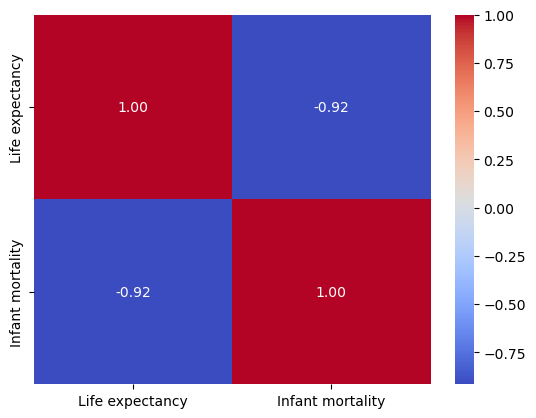

In [38]:
sns.heatmap(df_pair2_clean.loc[:, pair_2].corr(), annot=True, fmt=".2f", cmap='coolwarm')

Vemos que la correlación entre estas variables no cambiamucho al eliminar los outliers, lo que significa que la correlación de estas variables estaba bien marcada previo a la limpieza de los datos.

### Paso 5
Realiza lo mismo para comparar la cantidad de médicos por cada mil personas y la esperanza de vida. ¿Qué puedes concluir?

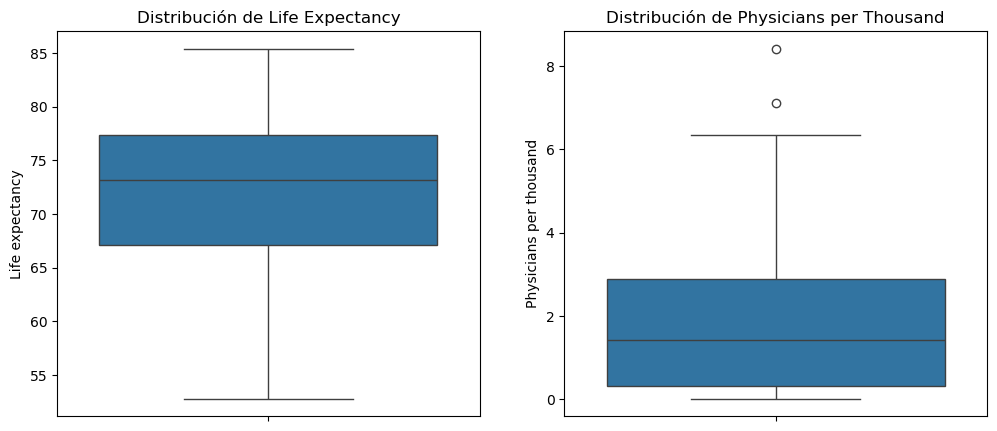

In [39]:
# Generamos un subset de los datos y limpiamos nulos
pair_3 = ['Life expectancy', 'Physicians per thousand']
df_pair3 = df_worlddata[pair_3].dropna().copy()

# Revisamos boxplots de las variables
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_pair3['Life expectancy'], ax=axes[0])
axes[0].set_title('Distribución de Life Expectancy')
sns.boxplot(data=df_pair3['Physicians per thousand'], ax=axes[1])
axes[1].set_title('Distribución de Physicians per Thousand')
plt.show()

Vemos que hay outliers presentes en la columna de médicos por cada mil personas, por lo que limpiaremos utilizando IQR.

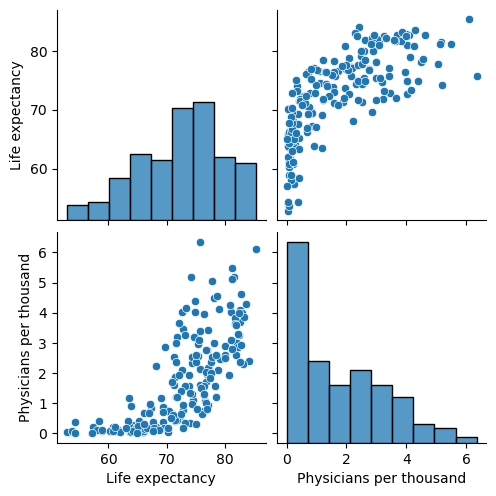

In [40]:
df_pair3_clean = remove_outliers_iqr(df_pair3, 'Physicians per thousand')
sns.pairplot(df_pair3_clean, vars=pair_3)

In [41]:
df_pair3.loc[:, pair_3].corr()

,Life expectancy,Physicians per thousand
Life expectancy,1.00000,0.70374
Physicians per thousand,0.70374,1.00000


<Axes: >

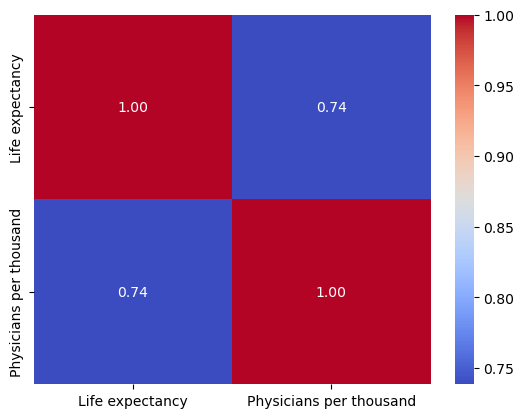

In [42]:
sns.heatmap(df_pair3_clean.loc[:, pair_3].corr(), annot=True, fmt=".2f", cmap='coolwarm')

Podemos ver que la esperanza de vida aumenta con la cantidad de médicos por cada mil personas, pero solo pasado cierto umbral (visualmente, entre 1 y 2 médicos por cada 1.000 personas). Previo a este umbral, la esperanza de vida se distribuye entre los 50 y 70 años. Luego, los datos posteriores a este umbral se encuentran mas dispersos por lo que no hay una correlación directa.

### Paso 6
Construye un gráfico para representar la población total de los países y su producto interno bruto.Prepara los datos y escoge el gráfico adecuado (si es necesario, limpia y/o transforma los datos). Justifica
___
Ya sabemos que el producto interno bruto (GDP) estaba expresado con el formato monetario ($\$100,000$), por lo que el tratamiento previo nos beneficia. Por lo tanto, debemos limpiar la data de población, y considerar transformar ambos datos dada la potencial diferencia en ordenes de magnitud de sus valores.

In [43]:
df_worlddata['Population'] = df_worlddata['Population']\
                        .str.replace('$', '')\
                        .str.replace(',', '')\
                        .astype(float)
display(df_worlddata['Population'].describe())

count    1.940000e+02
mean     3.938116e+07
std      1.450924e+08
min      8.360000e+02
25%      1.962678e+06
50%      8.826588e+06
75%      2.858549e+07
max      1.397715e+09
Name: Population, dtype: float64

In [44]:
print("Nulos GDP: ", df_worlddata['GDP'].isna().sum())
print("Nulos Population: ", df_worlddata['Population'].isna().sum())

Nulos GDP:  2
Nulos Population:  1


In [45]:
# Eliminamos los nulos en las columnas 'GDP' y 'Population'
pair_4 = ['GDP', 'Population']
df_pair4 = df_worlddata[pair_4].dropna().copy()

<Axes: ylabel='Population'>

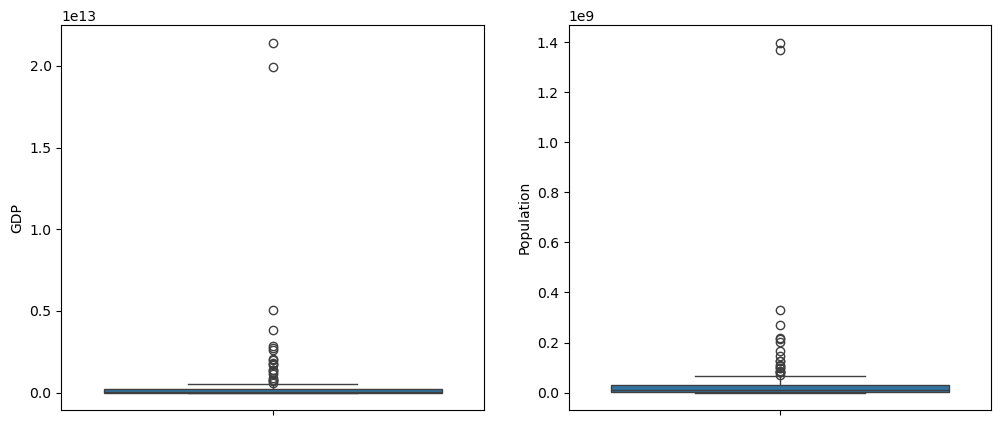

In [46]:
# Boxplots de las variables
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_pair4['GDP'], ax=axes[0])
sns.boxplot(data=df_pair4['Population'], ax=axes[1])


En ambos casos vemos una diferencia grande de ordenes de magnitud entre los datos. La mayor parte de estos se encuentra en los ordenes más bajos, con presencia de outliers hacia valores más altos. 

Primero, transformaremos estos datos para poder visualizarlos de mejor manera, y luego limpiaremos los outliers si es necesario.

<Axes: xlabel='log10_Population', ylabel='Count'>

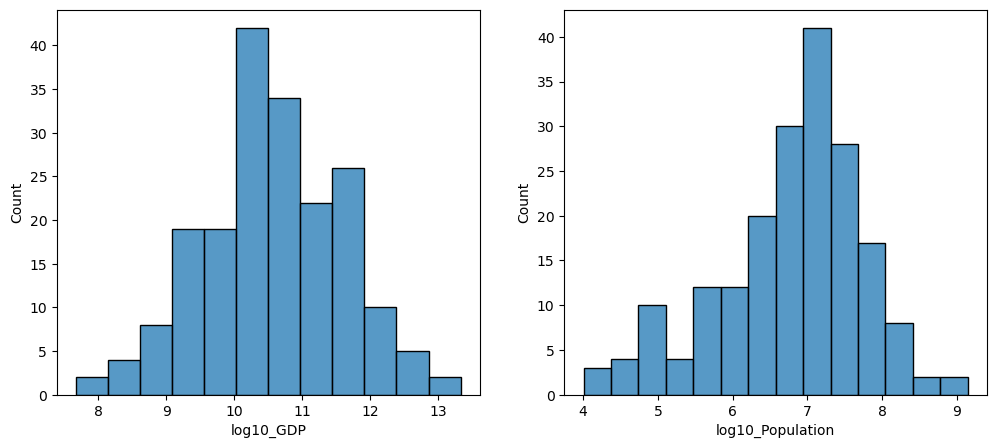

In [47]:
df_pair4['log10_GDP'] = np.log10(df_pair4['GDP'].replace(0, np.nan))
df_pair4['log10_Population'] = np.log10(df_pair4['Population'].replace(0, np.nan))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data=df_pair4['log10_GDP'], ax=axes[0])
sns.histplot(data=df_pair4['log10_Population'], ax=axes[1])

Ahora nuestros datos están mejor visualizados, solo hay que tener en cuenta que la diferencia entre cada barra del histograma representa un aumento de magnitud. En este caso al usar logaritmo en base 10, cada barra representa una potencia de 10 donde el valor en el eje X corresponde al exponente.

Comparemos visualmente ambos pares de datos (con y sin logaritmo aplicado)

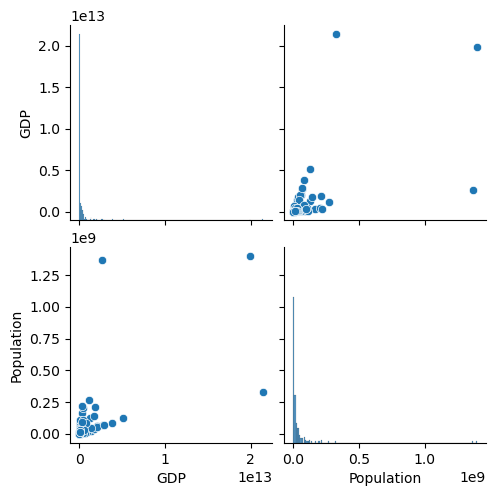

In [48]:
sns.pairplot(df_pair4, vars=['GDP', 'Population'])

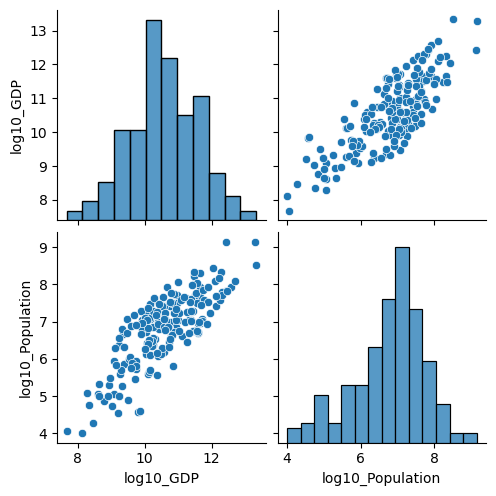

In [49]:
sns.pairplot(df_pair4, vars=['log10_GDP', 'log10_Population'])

Es claro que necesitabamos transformar los datos. Podemos ver claramente que el logaritmo de la población tiene correlación con el logaritmo del PIB (GDP). Ahora veremos si hay diferencias al eliminar los outliers utilizando el metodo IQR

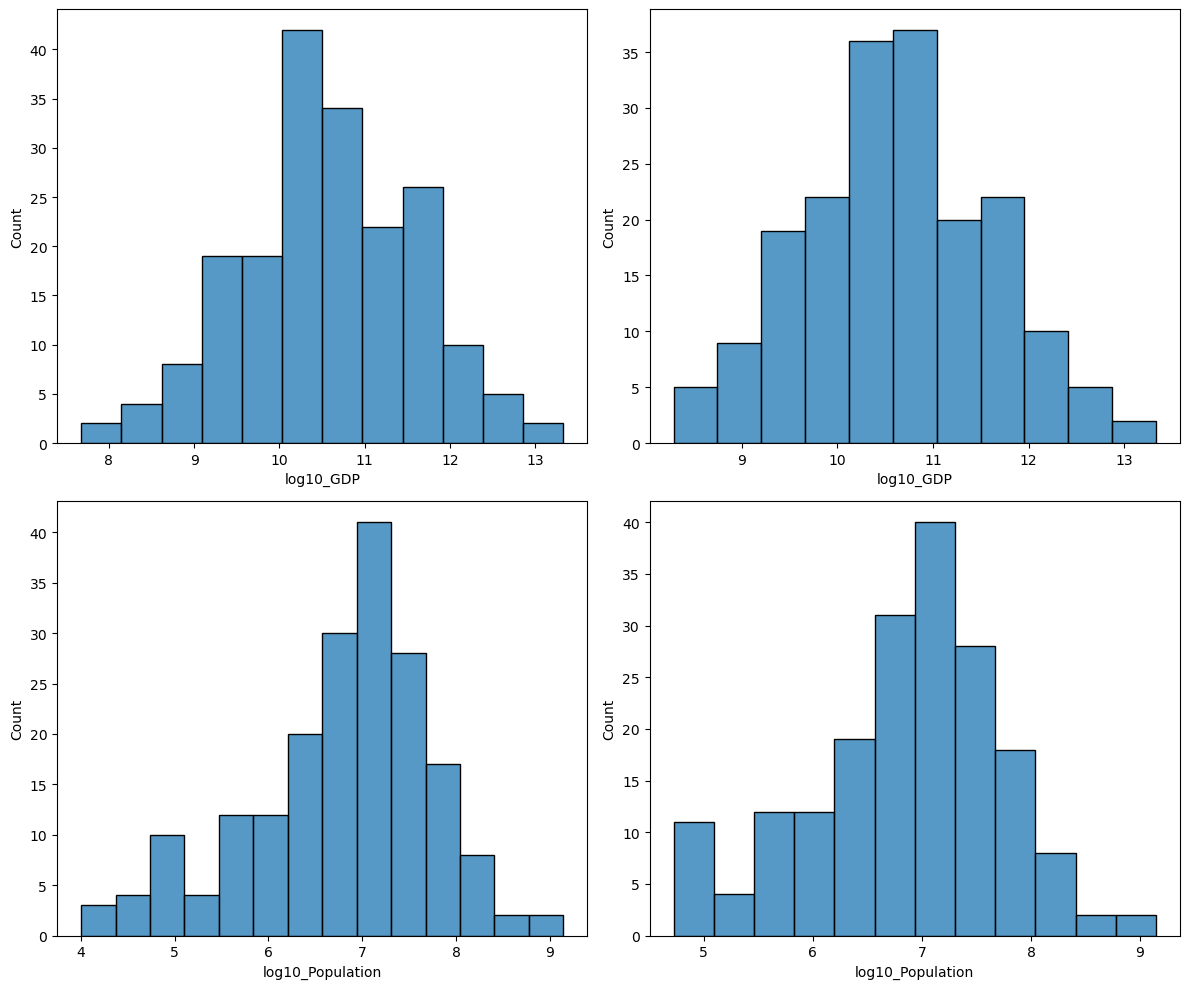

In [50]:
df_pair4_clean = remove_outliers_iqr(df_pair4, 'log10_GDP')
df_pair4_clean = remove_outliers_iqr(df_pair4_clean, 'log10_Population')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(data=df_pair4['log10_GDP'], ax=axes[0, 0])
sns.histplot(data=df_pair4_clean['log10_GDP'], ax=axes[0, 1])
sns.histplot(data=df_pair4['log10_Population'], ax=axes[1, 0])
sns.histplot(data=df_pair4_clean['log10_Population'], ax=axes[1, 1])
plt.tight_layout()
plt.show()

Vemos que las distribuciones se mantienen más bien similares para ambos casos. Ahora veamos las correlaciones.

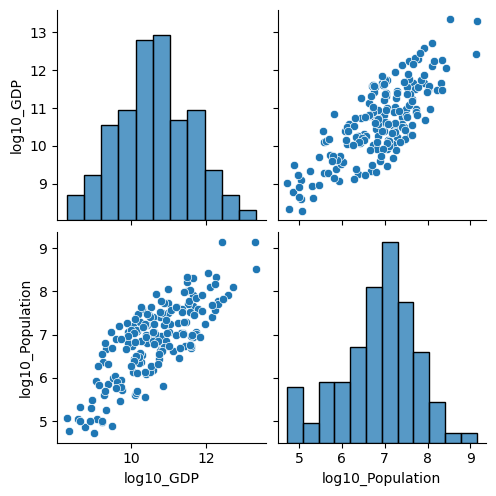

In [51]:
sns.pairplot(df_pair4_clean, vars=['log10_GDP', 'log10_Population'])

No se ven mayores diferencias al eliminar los valores atípicos. Ahora veamos la correlación de estas variables, y como se aprecia la diferencia entre comparar el logaritmo de las variables con respecto a su valor sin transformar.

In [52]:
pair_4_log = ['log10_GDP', 'log10_Population']
df_pair4_clean.loc[:, pair_4_log].corr()

,log10_GDP,log10_Population
log10_GDP,1.000000,0.781847
log10_Population,0.781847,1.000000


<Axes: >

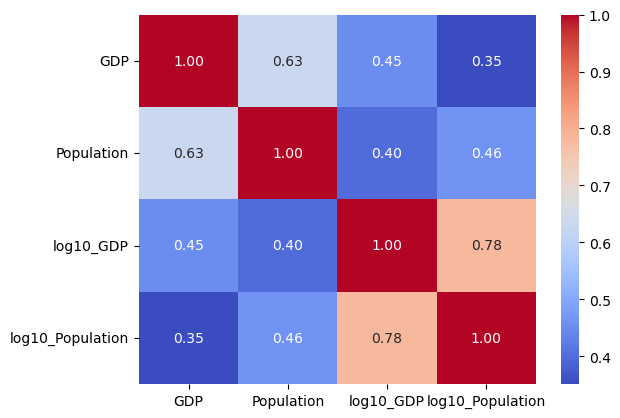

In [53]:
sns.heatmap(df_pair4_clean.loc[:, df_pair4_clean.columns].corr(), annot=True, fmt=".2f", cmap='coolwarm')

Este mapa de calor nos indica que hay una leve correlación entre el GDP y la población, pero es mucho más clara cuando aplicamos logaritmo a ambas variables. Esto se debe a que ambas variables abarcan varios ordenes de magnitudes, por lo que aplicar logaritmo nos 'aplana' los datos y facilita el análisis.

### Paso 7
Escoge otro par de datos, límpialos, prepáralos y analiza su posible relación. Justifica 
utilizando las herramientas vistas y gráficos adecuados.
___
Para finalizar, revisaremos si existe alguna relación entre la tasa de desempleo y el nivel de salario mínimo. La tasa se encuentra expresada como string con porcentaje, mientras que el salario mínimo esta expresado como monto (con signo $\$$)

In [54]:
df_worlddata['Minimum wage'] = df_worlddata['Minimum wage']\
                        .str.replace('$', '')\
                        .str.replace(',', '')\
                        .str.strip()\
                        .astype(float)
display(df_worlddata['Minimum wage'].describe())

count    150.000000
mean       2.194133
std        2.970796
min        0.010000
25%        0.402500
50%        1.045000
75%        2.447500
max       13.590000
Name: Minimum wage, dtype: float64

In [55]:
df_worlddata['Unemployment rate'] = df_worlddata['Unemployment rate']\
                        .str.replace('%', '')\
                        .astype(float)
display(df_worlddata['Unemployment rate'].describe())

count    176.000000
mean       6.886364
std        5.079216
min        0.090000
25%        3.395000
50%        5.360000
75%        9.490000
max       28.180000
Name: Unemployment rate, dtype: float64

In [56]:
print("Nulos Minimum wage: ", df_worlddata['Minimum wage'].isna().sum())
print("Nulos Unemployment rate: ", df_worlddata['Unemployment rate'].isna().sum())

Nulos Minimum wage:  45
Nulos Unemployment rate:  19


Vemos que hay una gran cantidad de nulos en ambas columnas. Limpiaremos los datos.

In [57]:
pair_5 = ['Minimum wage', 'Unemployment rate']
df_pair5 = df_worlddata[pair_5].dropna().copy()
df_pair5.describe().T

,count,mean,std,min,25%,50%,75%,max
Minimum wage,142.0,2.083944,2.916856,0.01,0.3925,0.965,2.225,13.59
Unemployment rate,142.0,6.816972,4.746344,0.47,3.4700,5.375,9.050,23.41


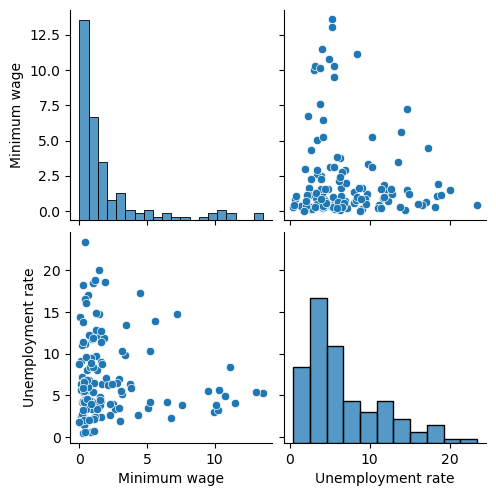

In [58]:
sns.pairplot(df_pair5, vars=pair_5)

A simple vista, no pareciera haber una relación clara entre el salario mínimo y la tasa de desempleo. Revisemos si hay datos atípicos.

<Axes: ylabel='Unemployment rate'>

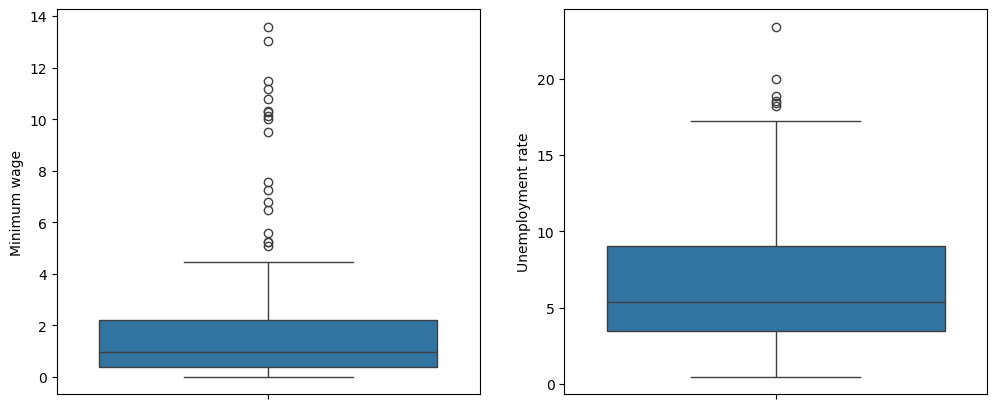

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_pair5['Minimum wage'], ax=axes[0])
sns.boxplot(data=df_pair5['Unemployment rate'], ax=axes[1])

Vemos varios datos atípicos. Limpiemos y revisemos nuevamente

<Axes: ylabel='Unemployment rate'>

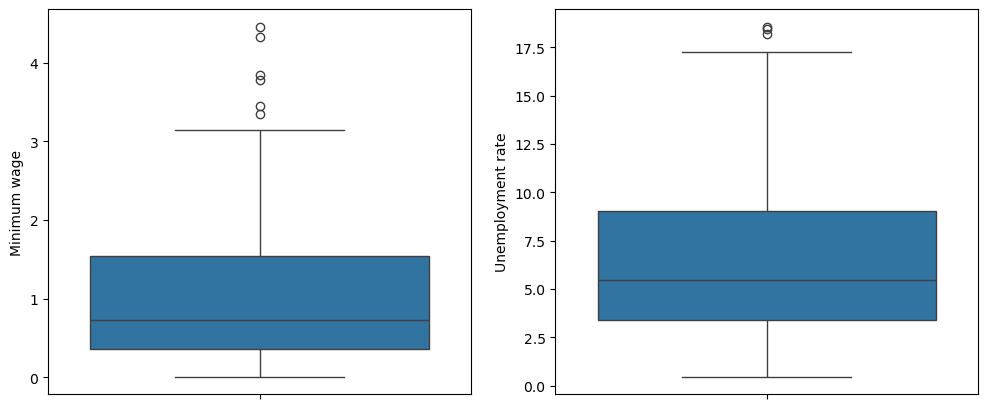

In [60]:
df_pair5_clean = remove_outliers_iqr(df_pair5, 'Minimum wage')
df_pair5_clean = remove_outliers_iqr(df_pair5_clean, 'Unemployment rate')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_pair5_clean['Minimum wage'], ax=axes[0])
sns.boxplot(data=df_pair5_clean['Unemployment rate'], ax=axes[1])

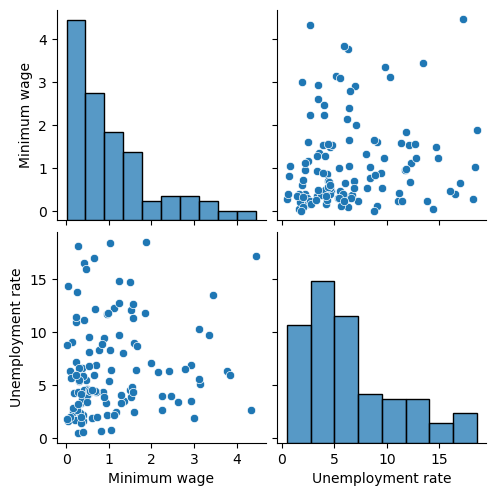

In [61]:
sns.pairplot(df_pair5_clean, vars=pair_5)

In [62]:
df_pair5_clean.loc[:, pair_5].corr()

,Minimum wage,Unemployment rate
Minimum wage,1.000000,0.126492
Unemployment rate,0.126492,1.000000


En conclusión, vemos que no existe una correlación lineal entre estas dos variables, ni antes ni después de limpiar los datos.